<a href="https://colab.research.google.com/github/israiqbal/ai-bias-app/blob/main/AI_Bias_Detection_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/saravrajavelu/Adult-Income-Analysis/master/adult.csv"
df = pd.read_csv(url)
#df = pd.read_csv("adult.csv")
df = df.dropna()

# Convert target
df['income'] = df['income'].apply(lambda x: 1 if ">50K" in x else 0)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['income'])
y = df['income']

X_encoded = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000, solver='liblinear')
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [ ]:
df_test = df.loc[y_test.index].copy()
df_test['pred'] = preds

male_rate = df_test[df_test['gender']=='Male']['pred'].mean()
female_rate = df_test[df_test['gender']=='Female']['pred'].mean()

dp_diff = abs(male_rate - female_rate)
di_ratio = female_rate / male_rate

print("Before Mitigation:")
print("Male:", male_rate)
print("Female:", female_rate)
print("Difference:", dp_diff)
print("Disparate Impact:", di_ratio)

Before Mitigation:
Male: 0.25341729381047456
Female: 0.07305095150399017
Difference: 0.1803663423064844
Disparate Impact: 0.2882634819651394


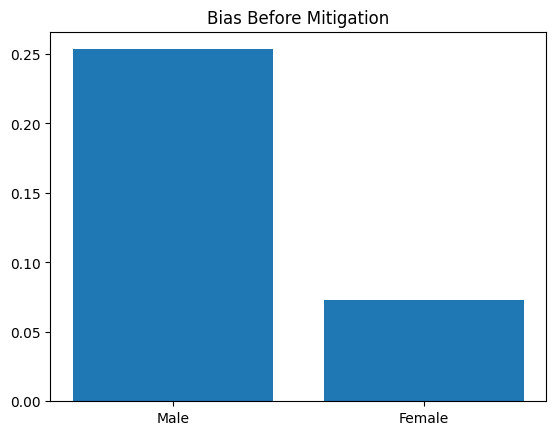

In [ ]:
import matplotlib.pyplot as plt

plt.bar(['Male','Female'], [male_rate, female_rate])
plt.title("Bias Before Mitigation")
plt.show()

In [ ]:
df_original = df.copy()

X_no_gender = df_original.drop(columns=['income', 'gender']) # Corrected 'sex' to 'gender'
y2 = df_original['income']

X_no_gender = pd.get_dummies(X_no_gender)

from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_gender, y2, test_size=0.2, random_state=42
)

# ✅ SAVE INDEX BEFORE SCALING
test_index = X_test2.index # Saved the index of X_test2
# Removed the problematic line: X_test2 = pd.DataFrame(X_test2, index=test_index)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler(with_mean=False)

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

In [ ]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=5000, solver='liblinear')
model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)

In [ ]:
df_test2 = df_original.loc[test_index].copy()
df_test2['pred'] = preds2

male_rate2 = df_test2[df_test2['gender']=='Male']['pred'].mean()
female_rate2 = df_test2[df_test2['gender']=='Female']['pred'].mean()

print("After Mitigation:")
print("Male:", male_rate2)
print("Female:", female_rate2)

After Mitigation:
Male: 0.25034556903701427
Female: 0.07550644567219153


In [ ]:
print("Before:", male_rate, female_rate)
print("After:", male_rate2, female_rate2)

reduction = abs(male_rate - female_rate) - abs(male_rate2 - female_rate2)
print("Bias Reduction:", reduction)

Before: 0.25341729381047456 0.07305095150399017
After: 0.25034556903701427 0.07550644567219153
Bias Reduction: 0.005527218941661666


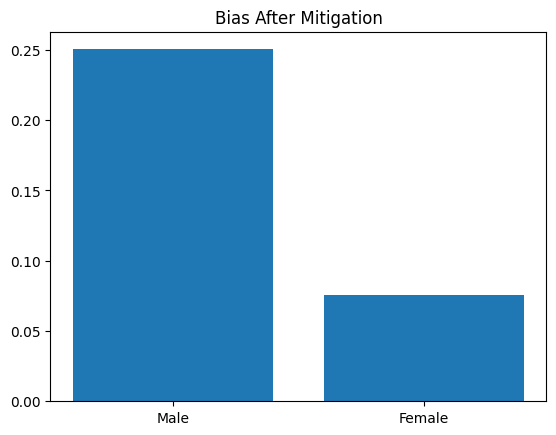

In [ ]:
import matplotlib.pyplot as plt

plt.bar(['Male','Female'], [male_rate2, female_rate2])
plt.title("Bias After Mitigation")
plt.show()

In [ ]:
def explain_bias_advanced(male_rate, female_rate, di_ratio):
    diff = abs(male_rate - female_rate)

    if di_ratio < 0.8:
        severity = "High"
        reason = "significant imbalance in selection rates"
    elif diff > 0.1:
        severity = "Moderate"
        reason = "noticeable difference between groups"
    else:
        severity = "Low"
        reason = "fairly balanced predictions"

    explanation = f"""
    🔍 Bias Analysis Report

    The model shows {severity} bias due to {reason}.

    📊 Key Observations:
    - Male approval rate: {male_rate:.2f}
    - Female approval rate: {female_rate:.2f}
    - Difference: {diff:.2f}
    - Disparate Impact Ratio: {di_ratio:.2f}

    🧠 Interpretation:
    The model appears to favor one group over the other, which may stem from biased training data.

    🛠 Suggested Fix:
    Removing sensitive attributes like gender helped reduce this imbalance and improve fairness.Mitigation helped reduce bias by removing sensitive feature.


    ⚠️ Recommendation:
    Further techniques like reweighting or fairness constraints can be applied.
    """
    return explanation
explanation = explain_bias_advanced(male_rate2, female_rate2, di_ratio)
print("="*50)
print("BIAS ANALYSIS REPORT")
print("="*50)
print(explanation)

BIAS ANALYSIS REPORT

    🔍 Bias Analysis Report

    The model shows High bias due to significant imbalance in selection rates.

    📊 Key Observations:
    - Male approval rate: 0.25
    - Female approval rate: 0.08
    - Difference: 0.17
    - Disparate Impact Ratio: 0.29

    🧠 Interpretation:
    The model appears to favor one group over the other, which may stem from biased training data.

    🛠 Suggested Fix:
    Removing sensitive attributes like gender helped reduce this imbalance and improve fairness.Mitigation helped reduce bias by removing sensitive feature.


    ⚠️ Recommendation:
    Further techniques like reweighting or fairness constraints can be applied.
    
